# Goose Bay Robustness Notebook

This notebook addresses the ionosphere discrepancy raised during the D002 cross-domain analysis. Its purpose is to determine whether the difference between the 2022 Goose Bay result and the newer generic transfer probe is primarily due to:

1. train/test split choice,
2. rectification rule, or
3. sparse-penalty strength.


## Experiment Design

The notebook uses the UCI ionosphere dataset in four protocol variants:

1. **Generic probe**: the same standardized protocol used in `cross_domain.ipynb` (`70/30` split, `cutlass` rectification, `C=0.1`).
2. **Split-matched cutlass**: same rectification and penalty as the generic probe, but with a Goose Bay style `67/33` class-stratified split.
3. **Legacy rectifier bridge**: same Goose Bay style split, but replacing the generic quantile rectifier with a legacy-style positive-range min/max rectifier while keeping `C=0.1`.
4. **Published-like legacy**: same Goose Bay style split and legacy rectifier, but using a much weaker penalty (`C=10`) that better mimics the least-penalized behavior of the original LLE pipeline.

The repeated-split experiment runs all four protocols over a fixed seed set, then summarizes:

- `delta_j = rectified_j - raw_j`
- `delta_tpr = rectified_tpr - raw_tpr`
- `delta_tnr = rectified_tnr - raw_tnr`
- the fraction of seeds where rectification beats raw

Later sensitivity cells also:

- sweep several `cutlass` quantile settings under the Goose Bay-style `67/33` split while holding `C=0.1` fixed, and
- sweep 100 log-uniform `C` values from `0.01` to `100` under the Goose Bay-style `67/33` split with min/max rectification.

The 2022 paper values are also recorded as a separate reference point rather than being conflated with the standardized generic probe.


In [92]:
from __future__ import annotations

import importlib
import json
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from IPython.display import display
except Exception:
    display = None

for module_name in [name for name in list(globals()) if name == "cutlass" or str(name).startswith("cutlass.")]:
    pass

cutlass = importlib.import_module("cutlass")
DuplicateColumnConsolidator = cutlass.DuplicateColumnConsolidator
Rectifier = cutlass.Rectifier

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True


In [93]:
def _find_repo_root() -> Path:
    anchors = [Path.cwd().resolve()]
    if "__file__" in globals():
        anchors.insert(0, Path(__file__).resolve().parent)
    for anchor in anchors:
        for candidate in (anchor, *anchor.parents):
            if (candidate / "scripts").is_dir() and (candidate / "notebooks").is_dir():
                return candidate
    raise FileNotFoundError("Could not locate the dissertation repository root.")


REPO_ROOT = _find_repo_root()
NOTEBOOKS_DIR = REPO_ROOT / "notebooks"
RAW_DATA_DIR = NOTEBOOKS_DIR / "raw_data"
FIGURES_DIR = NOTEBOOKS_DIR / "Figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RUN_DIR = NOTEBOOKS_DIR / "runs_new" / "goose_bay_robustness"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Figures directory:", FIGURES_DIR)
print("Run directory:", RUN_DIR)


Repository root: C:\Users\jason\ODU\dissertation
Figures directory: C:\Users\jason\ODU\dissertation\notebooks\Figures
Run directory: C:\Users\jason\ODU\dissertation\notebooks\runs_new\goose_bay_robustness


In [94]:
DATA_PATH = RAW_DATA_DIR / "ionosphere.data"
PAPER_REFERENCE = {
    "raw_tpr": 0.933,
    "raw_tnr": 0.762,
    "rect_tpr": 0.973,
    "rect_tnr": 0.881,
}
PAPER_REFERENCE["raw_j"] = PAPER_REFERENCE["raw_tpr"] + PAPER_REFERENCE["raw_tnr"] - 1.0
PAPER_REFERENCE["rect_j"] = PAPER_REFERENCE["rect_tpr"] + PAPER_REFERENCE["rect_tnr"] - 1.0
PAPER_REFERENCE["delta_j"] = PAPER_REFERENCE["rect_j"] - PAPER_REFERENCE["raw_j"]
CUTLASS_RECTIFIER_KW = dict(sdfilter=None, snap=0.001, quantile_bounds=(0.25, 0.75))
MINMAX_RECTIFIER_KW = dict(sdfilter=None, snap=0.0, quantile_bounds=None)
C_SWEEP_RANDOM_SEED = 42
C_SWEEP_VALUES = np.sort(
    np.power(
        10.0,
        np.random.RandomState(C_SWEEP_RANDOM_SEED).uniform(-2.0, 2.0, size=100),
    )
)
C_SWEEP_SPLIT = "legacy67"
C_SWEEP_RECTIFIER_KW = MINMAX_RECTIFIER_KW
C_SWEEP_CV_FOLDS = 10
QUANTILE_SWEEP = [
    {"id": "q10_90", "label": "10/90", "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.10, 0.90))},
    {"id": "q20_80", "label": "20/80", "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.20, 0.80))},
    {"id": "q25_75", "label": "25/75 (default)", "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.25, 0.75))},
    {"id": "q30_70", "label": "30/70", "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.30, 0.70))},
    {"id": "q35_65", "label": "35/65", "rectifier_kw": dict(sdfilter=None, snap=0.001, quantile_bounds=(0.35, 0.65))},
]
QUANTILE_SWEEP_ORDER = [item["id"] for item in QUANTILE_SWEEP]

PROTOCOLS = [
    {
        "id": "generic_probe",
        "label": "Generic probe",
        "split": "generic70",
        "raw_c": 0.1,
        "rectifier": "quantile",
        "rectifier_kw": CUTLASS_RECTIFIER_KW,
        "rect_c": 0.1,
    },
    {
        "id": "matched_split_cutlass",
        "label": "Split-matched cutlass",
        "split": "legacy67",
        "raw_c": 0.1,
        "rectifier": "quantile",
        "rectifier_kw": CUTLASS_RECTIFIER_KW,
        "rect_c": 0.1,
    },
    {
        "id": "legacy_rectifier_bridge",
        "label": "Legacy rectifier bridge",
        "split": "legacy67",
        "raw_c": 0.1,
        "rectifier": "minmax",
        "rectifier_kw": MINMAX_RECTIFIER_KW,
        "rect_c": 0.1,
    },
    {
        "id": "published_like_legacy",
        "label": "Published-like legacy",
        "split": "legacy67",
        "raw_c": 10.0,
        "rectifier": "minmax",
        "rectifier_kw": MINMAX_RECTIFIER_KW,
        "rect_c": 10.0,
    },
]
PROTOCOL_ORDER = [item["id"] for item in PROTOCOLS]
PROTOCOL_LABELS = {item["id"]: item["label"] for item in PROTOCOLS}
PROTOCOL_DISPLAY = {
    "generic_probe": "Generic probe\n70/30, cutlass, C=0.1",
    "matched_split_cutlass": "Split-matched cutlass\n67/33, cutlass, C=0.1",
    "legacy_rectifier_bridge": "Legacy rectifier bridge\n67/33, min/max, C=0.1",
    "published_like_legacy": "Published-like legacy\n67/33, min/max, C=10",
}
PROTOCOL_COLORS = {
    "generic_probe": "#7f8c8d",
    "matched_split_cutlass": "#4c78a8",
    "legacy_rectifier_bridge": "#f28e2b",
    "published_like_legacy": "#2ca02c",
}
EVAL_SEEDS = list(range(100)) + [2345]

ionosphere_raw = pd.read_csv(DATA_PATH, header=None)
X_FULL = ionosphere_raw.iloc[:, :-1].copy()
X_FULL.columns = [f"F{i:02d}" for i in range(X_FULL.shape[1])]
Y_FULL = (ionosphere_raw.iloc[:, -1] == "g").astype(int).to_numpy()

config_view = pd.DataFrame(
    [
        {"Parameter": "Dataset", "Value": str(DATA_PATH)},
        {"Parameter": "Seed count", "Value": len(EVAL_SEEDS)},
        {"Parameter": "Special seed", "Value": 2345},
        {"Parameter": "Protocols", "Value": ", ".join(item["id"] for item in PROTOCOLS)},
        {"Parameter": "Paper reference delta J", "Value": f"{PAPER_REFERENCE['delta_j']:.3f}"},
    ]
)
if display is not None:
    display(config_view)
else:
    print(config_view.to_string(index=False))


,Parameter,Value
0,Dataset,C:\Users\jason\ODU\dissertation\notebooks\raw_...
1,Seed count,101
2,Special seed,2345
3,Protocols,"generic_probe, matched_split_cutlass, legacy_r..."
4,Paper reference delta J,0.159


In [95]:
def format_numeric(value: float, digits: int = 3) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{float(value):.{digits}f}"


def unpack_quantile_bounds(rectifier_kw: dict) -> tuple[float | None, float | None]:
    bounds = rectifier_kw.get("quantile_bounds")
    if bounds is None:
        return np.nan, np.nan
    return float(bounds[0]), float(bounds[1])


def split_r_like(seed: int, train_frac: float = 0.67):
    pos_idx = np.flatnonzero(Y_FULL == 1)
    neg_idx = np.flatnonzero(Y_FULL == 0)
    rng = np.random.RandomState(seed)
    pos_train = rng.choice(pos_idx, size=int(train_frac * len(pos_idx)), replace=False)
    neg_train = rng.choice(neg_idx, size=int(train_frac * len(neg_idx)), replace=False)
    train_idx = np.sort(np.concatenate([pos_train, neg_train]))
    test_mask = np.ones(len(Y_FULL), dtype=bool)
    test_mask[train_idx] = False
    test_idx = np.flatnonzero(test_mask)
    return (
        X_FULL.iloc[train_idx].reset_index(drop=True),
        X_FULL.iloc[test_idx].reset_index(drop=True),
        Y_FULL[train_idx],
        Y_FULL[test_idx],
    )


def split_generic(seed: int, test_size: float = 0.30):
    X_train, X_test, y_train, y_test = train_test_split(
        X_FULL,
        Y_FULL,
        test_size=test_size,
        stratify=Y_FULL,
        random_state=seed,
    )
    return X_train.reset_index(drop=True), X_test.reset_index(drop=True), y_train, y_test


def score_at_threshold(y_true, prob, threshold: float = 0.5) -> dict:
    y_arr = np.asarray(y_true).astype(int)
    prob_arr = np.asarray(prob, dtype=float)
    pred = (prob_arr >= threshold).astype(int)
    positives = y_arr == 1
    negatives = y_arr == 0
    tpr = float(np.mean(pred[positives] == 1))
    tnr = float(np.mean(pred[negatives] == 0))
    return {
        "j": float(tpr + tnr - 1.0),
        "tpr": tpr,
        "tnr": tnr,
    }


def fit_sparse_logistic(X_train, y_train, X_test, y_test, *, C: float, standardize: bool) -> dict:
    Xtr = X_train
    Xte = X_test
    if standardize:
        scaler = StandardScaler().fit(X_train)
        Xtr = scaler.transform(X_train)
        Xte = scaler.transform(X_test)

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(C),
        max_iter=12000,
        tol=1e-4,
        random_state=42,
    )
    model.fit(Xtr, y_train)
    prob = model.predict_proba(Xte)[:, 1]
    threshold_metrics = score_at_threshold(y_test, prob, threshold=0.5)
    return {
        "j": threshold_metrics["j"],
        "tpr": threshold_metrics["tpr"],
        "tnr": threshold_metrics["tnr"],
        "nonzero_total": int((model.coef_.ravel() != 0).sum()),
    }


def fit_sparse_logistic_path(
    X_train,
    y_train,
    X_test,
    y_test,
    *,
    c_values,
    standardize: bool,
) -> list[dict]:
    Xtr = X_train
    Xte = X_test
    if standardize:
        scaler = StandardScaler().fit(X_train)
        Xtr = scaler.transform(X_train)
        Xte = scaler.transform(X_test)

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=float(c_values[0]),
        max_iter=12000,
        tol=1e-4,
        random_state=42,
        warm_start=True,
    )
    rows = []
    for c_value in c_values:
        model.set_params(C=float(c_value))
        model.fit(Xtr, y_train)
        prob = model.predict_proba(Xte)[:, 1]
        threshold_metrics = score_at_threshold(y_test, prob, threshold=0.5)
        rows.append(
            {
                "c_value": float(c_value),
                "j": threshold_metrics["j"],
                "tpr": threshold_metrics["tpr"],
                "tnr": threshold_metrics["tnr"],
                "nonzero_total": int((model.coef_.ravel() != 0).sum()),
            }
        )
    return rows


def cutlass_rectify(
    X_train: pd.DataFrame,
    y_train: np.ndarray,
    X_test: pd.DataFrame,
    *,
    rectifier_kw: dict | None = None,
):
    active_rectifier_kw = dict(CUTLASS_RECTIFIER_KW if rectifier_kw is None else rectifier_kw)
    rectifier = Rectifier(groups=None, **active_rectifier_kw)
    X_train_rect = rectifier.fit_transform(X_train, y_train)
    X_test_rect = rectifier.transform(X_test)
    consolidator = DuplicateColumnConsolidator(mode="none", expansion="split_evenly")
    X_train_fit = consolidator.fit_transform(X_train_rect, feature_names=rectifier.feature_names_)
    X_test_fit = consolidator.transform(X_test_rect, feature_names=rectifier.feature_names_)
    return X_train_fit, X_test_fit


In [96]:
def run_or_load_repeated_protocol_ablation(overwrite_cache: bool = False) -> pd.DataFrame:
    cache_path = RUN_DIR / "goose_bay_repeated_protocol_runs.csv"
    if cache_path.exists() and not overwrite_cache:
        df = pd.read_csv(cache_path)
        required_cols = {
            "seed",
            "protocol",
            "protocol_label",
            "split",
            "rectifier",
            "rectifier_quantile_low",
            "rectifier_quantile_high",
            "rectifier_snap",
            "rectifier_sdfilter",
            "raw_c",
            "rect_c",
            "raw_j",
            "rect_j",
            "delta_j",
            "raw_tpr",
            "rect_tpr",
            "delta_tpr",
            "raw_tnr",
            "rect_tnr",
            "delta_tnr",
            "raw_nonzero",
            "rect_nonzero",
        }
        if required_cols.issubset(df.columns):
            print("Loaded repeated protocol ablation from:", cache_path)
            return df
        print("Repeated-protocol cache is missing required columns. Recomputing:", cache_path)

    rows = []
    start = perf_counter()

    for index, seed in enumerate(EVAL_SEEDS):
        split_cache = {}
        for protocol in PROTOCOLS:
            split_key = protocol["split"]
            if split_key not in split_cache:
                if split_key == "legacy67":
                    split_cache[split_key] = split_r_like(seed, train_frac=0.67)
                else:
                    split_cache[split_key] = split_generic(seed, test_size=0.30)
            X_train, X_test, y_train, y_test = split_cache[split_key]

            raw_result = fit_sparse_logistic(
                X_train,
                y_train,
                X_test,
                y_test,
                C=protocol["raw_c"],
                standardize=True,
            )

            rectifier_qlo, rectifier_qhi = unpack_quantile_bounds(protocol["rectifier_kw"])
            X_train_rect, X_test_rect = cutlass_rectify(
                X_train,
                y_train,
                X_test,
                rectifier_kw=protocol["rectifier_kw"],
            )

            rect_result = fit_sparse_logistic(
                X_train_rect,
                y_train,
                X_test_rect,
                y_test,
                C=protocol["rect_c"],
                standardize=False,
            )

            rows.append(
                {
                    "seed": int(seed),
                    "protocol": protocol["id"],
                    "protocol_label": protocol["label"],
                    "split": protocol["split"],
                    "rectifier": protocol["rectifier"],
                    "rectifier_quantile_low": rectifier_qlo,
                    "rectifier_quantile_high": rectifier_qhi,
                    "rectifier_snap": float(protocol["rectifier_kw"]["snap"]) if protocol["rectifier_kw"]["snap"] is not None else np.nan,
                    "rectifier_sdfilter": float(protocol["rectifier_kw"]["sdfilter"]) if protocol["rectifier_kw"]["sdfilter"] is not None else np.nan,
                    "raw_c": float(protocol["raw_c"]),
                    "rect_c": float(protocol["rect_c"]),
                    "raw_j": raw_result["j"],
                    "rect_j": rect_result["j"],
                    "delta_j": rect_result["j"] - raw_result["j"],
                    "raw_tpr": raw_result["tpr"],
                    "rect_tpr": rect_result["tpr"],
                    "delta_tpr": rect_result["tpr"] - raw_result["tpr"],
                    "raw_tnr": raw_result["tnr"],
                    "rect_tnr": rect_result["tnr"],
                    "delta_tnr": rect_result["tnr"] - raw_result["tnr"],
                    "raw_nonzero": raw_result["nonzero_total"],
                    "rect_nonzero": rect_result["nonzero_total"],
                }
            )

        if index % 20 == 0:
            print(f"Completed seed {index + 1} / {len(EVAL_SEEDS)}")

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    print(f"Saved repeated protocol ablation to: {cache_path} ({perf_counter() - start:.2f}s)")
    return df


repeated_runs = run_or_load_repeated_protocol_ablation(overwrite_cache=False)
if display is not None:
    display(repeated_runs.head())
else:
    print(repeated_runs.head().to_string(index=False))


Loaded repeated protocol ablation from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\goose_bay_robustness\goose_bay_repeated_protocol_runs.csv


,seed,protocol,protocol_label,split,rectifier,rectifier_quantile_low,rectifier_quantile_high,rectifier_snap,rectifier_sdfilter,raw_c,...,rect_j,delta_j,raw_tpr,rect_tpr,delta_tpr,raw_tnr,rect_tnr,delta_tnr,raw_nonzero,rect_nonzero
0,0,generic_probe,Generic probe,generic70,quantile,0.25,0.75,0.001,NaN,0.1,...,0.777090,0.189628,0.955882,0.882353,-0.073529,0.631579,0.894737,0.263158,8,11
1,0,matched_split_cutlass,Split-matched cutlass,legacy67,quantile,0.25,0.75,0.001,NaN,0.1,...,0.716190,0.079048,0.946667,0.906667,-0.040000,0.690476,0.809524,0.119048,6,12
2,0,legacy_rectifier_bridge,Legacy rectifier bridge,legacy67,minmax,NaN,NaN,0.000,NaN,0.1,...,0.714286,0.077143,0.946667,1.000000,0.053333,0.690476,0.714286,0.023810,6,8
3,0,published_like_legacy,Published-like legacy,legacy67,minmax,NaN,NaN,0.000,NaN,10.0,...,0.843810,0.117143,0.893333,0.986667,0.093333,0.833333,0.857143,0.023810,30,32
4,1,generic_probe,Generic probe,generic70,quantile,0.25,0.75,0.001,NaN,0.1,...,0.794892,0.136997,1.000000,0.926471,-0.073529,0.657895,0.868421,0.210526,10,12


In [97]:
protocol_summary = (
    repeated_runs.groupby(["protocol", "protocol_label"], as_index=False)
    .agg(
        mean_delta_j=("delta_j", "mean"),
        median_delta_j=("delta_j", "median"),
        p05_delta_j=("delta_j", lambda s: float(np.quantile(s, 0.05))),
        p95_delta_j=("delta_j", lambda s: float(np.quantile(s, 0.95))),
        positive_fraction=("delta_j", lambda s: float((s > 0).mean())),
        mean_delta_tpr=("delta_tpr", "mean"),
        mean_delta_tnr=("delta_tnr", "mean"),
        mean_raw_j=("raw_j", "mean"),
        mean_rect_j=("rect_j", "mean"),
        mean_raw_nonzero=("raw_nonzero", "mean"),
        mean_rect_nonzero=("rect_nonzero", "mean"),
    )
)
protocol_summary["protocol"] = pd.Categorical(protocol_summary["protocol"], categories=PROTOCOL_ORDER, ordered=True)
protocol_summary = protocol_summary.sort_values("protocol").reset_index(drop=True)
protocol_summary.to_csv(RUN_DIR / "goose_bay_protocol_summary.csv", index=False)

protocol_summary_formatted = protocol_summary.copy()
for column in [
    "mean_delta_j",
    "median_delta_j",
    "p05_delta_j",
    "p95_delta_j",
    "positive_fraction",
    "mean_delta_tpr",
    "mean_delta_tnr",
    "mean_raw_j",
    "mean_rect_j",
    "mean_raw_nonzero",
    "mean_rect_nonzero",
]:
    protocol_summary_formatted[column] = protocol_summary_formatted[column].map(lambda value: format_numeric(value, 3))
protocol_summary_formatted.to_csv(RUN_DIR / "goose_bay_protocol_summary_formatted.csv", index=False)

if display is not None:
    display(protocol_summary_formatted)
else:
    print(protocol_summary_formatted.to_string(index=False))


,protocol,protocol_label,mean_delta_j,median_delta_j,p05_delta_j,p95_delta_j,positive_fraction,mean_delta_tpr,mean_delta_tnr,mean_raw_j,mean_rect_j,mean_raw_nonzero,mean_rect_nonzero
0,generic_probe,Generic probe,0.006,0.012,-0.126,0.155,0.564,-0.069,0.075,0.645,0.651,8.198,11.703
1,matched_split_cutlass,Split-matched cutlass,0.003,0.005,-0.133,0.140,0.505,-0.081,0.084,0.639,0.642,7.802,11.515
2,legacy_rectifier_bridge,Legacy rectifier bridge,0.066,0.071,-0.048,0.180,0.851,0.007,0.059,0.639,0.705,7.802,6.960
3,published_like_legacy,Published-like legacy,0.148,0.146,0.040,0.249,1.000,0.006,0.142,0.684,0.832,31.406,26.000


In [98]:
def run_or_load_quantile_sweep(overwrite_cache: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    cache_path = RUN_DIR / "goose_bay_quantile_sweep_runs.csv"
    required_cols = {
        "seed",
        "quantile_id",
        "quantile_label",
        "split",
        "raw_c",
        "rect_c",
        "quantile_low",
        "quantile_high",
        "raw_j",
        "rect_j",
        "delta_j",
        "raw_tpr",
        "rect_tpr",
        "delta_tpr",
        "raw_tnr",
        "rect_tnr",
        "delta_tnr",
        "raw_nonzero",
        "rect_nonzero",
    }
    if cache_path.exists() and not overwrite_cache:
        quantile_runs = pd.read_csv(cache_path)
        if required_cols.issubset(quantile_runs.columns):
            print("Loaded quantile sweep from:", cache_path)
        else:
            print("Quantile-sweep cache is missing required columns. Recomputing:", cache_path)
            quantile_runs = None
    else:
        quantile_runs = None

    if quantile_runs is None:
        rows = []
        start = perf_counter()
        for seed in EVAL_SEEDS:
            X_train, X_test, y_train, y_test = split_r_like(seed, train_frac=0.67)
            raw_result = fit_sparse_logistic(
                X_train,
                y_train,
                X_test,
                y_test,
                C=0.1,
                standardize=True,
            )
            for spec in QUANTILE_SWEEP:
                quantile_low, quantile_high = unpack_quantile_bounds(spec["rectifier_kw"])
                X_train_rect, X_test_rect = cutlass_rectify(
                    X_train,
                    y_train,
                    X_test,
                    rectifier_kw=spec["rectifier_kw"],
                )
                rect_result = fit_sparse_logistic(
                    X_train_rect,
                    y_train,
                    X_test_rect,
                    y_test,
                    C=0.1,
                    standardize=False,
                )
                rows.append(
                    {
                        "seed": int(seed),
                        "quantile_id": spec["id"],
                        "quantile_label": spec["label"],
                        "split": "legacy67",
                        "raw_c": 0.1,
                        "rect_c": 0.1,
                        "quantile_low": quantile_low,
                        "quantile_high": quantile_high,
                        "raw_j": raw_result["j"],
                        "rect_j": rect_result["j"],
                        "delta_j": rect_result["j"] - raw_result["j"],
                        "raw_tpr": raw_result["tpr"],
                        "rect_tpr": rect_result["tpr"],
                        "delta_tpr": rect_result["tpr"] - raw_result["tpr"],
                        "raw_tnr": raw_result["tnr"],
                        "rect_tnr": rect_result["tnr"],
                        "delta_tnr": rect_result["tnr"] - raw_result["tnr"],
                        "raw_nonzero": raw_result["nonzero_total"],
                        "rect_nonzero": rect_result["nonzero_total"],
                    }
                )
        quantile_runs = pd.DataFrame(rows)
        quantile_runs.to_csv(cache_path, index=False)
        print(f"Saved quantile sweep to: {cache_path} ({perf_counter() - start:.2f}s)")

    quantile_summary = (
        quantile_runs.groupby(["quantile_id", "quantile_label"], as_index=False)
        .agg(
            mean_delta_j=("delta_j", "mean"),
            median_delta_j=("delta_j", "median"),
            p05_delta_j=("delta_j", lambda s: float(np.quantile(s, 0.05))),
            p95_delta_j=("delta_j", lambda s: float(np.quantile(s, 0.95))),
            positive_fraction=("delta_j", lambda s: float((s > 0).mean())),
            mean_delta_tpr=("delta_tpr", "mean"),
            mean_delta_tnr=("delta_tnr", "mean"),
            mean_rect_nonzero=("rect_nonzero", "mean"),
        )
    )
    seed_2345_lookup = (
        quantile_runs.loc[quantile_runs["seed"] == 2345, ["quantile_id", "delta_j"]]
        .drop_duplicates("quantile_id")
        .set_index("quantile_id")["delta_j"]
    )
    quantile_summary["seed_2345_delta_j"] = quantile_summary["quantile_id"].map(seed_2345_lookup)
    quantile_summary["quantile_id"] = pd.Categorical(
        quantile_summary["quantile_id"],
        categories=QUANTILE_SWEEP_ORDER,
        ordered=True,
    )
    quantile_summary = quantile_summary.sort_values("quantile_id").reset_index(drop=True)
    quantile_summary.to_csv(RUN_DIR / "goose_bay_quantile_sweep_summary.csv", index=False)
    return quantile_runs, quantile_summary


quantile_sweep_runs, quantile_sweep_summary = run_or_load_quantile_sweep(overwrite_cache=False)
quantile_sweep_summary_formatted = quantile_sweep_summary.copy()
for column in [
    "mean_delta_j",
    "median_delta_j",
    "p05_delta_j",
    "p95_delta_j",
    "positive_fraction",
    "mean_delta_tpr",
    "mean_delta_tnr",
    "mean_rect_nonzero",
    "seed_2345_delta_j",
]:
    quantile_sweep_summary_formatted[column] = quantile_sweep_summary_formatted[column].map(
        lambda value: format_numeric(value, 3)
    )
quantile_sweep_summary_formatted.to_csv(
    RUN_DIR / "goose_bay_quantile_sweep_summary_formatted.csv",
    index=False,
)

print("Quantile sweep under Goose Bay 67/33 split and C=0.1:")
if display is not None:
    display(quantile_sweep_summary_formatted)
else:
    print(quantile_sweep_summary_formatted.to_string(index=False))


Loaded quantile sweep from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\goose_bay_robustness\goose_bay_quantile_sweep_runs.csv
Quantile sweep under Goose Bay 67/33 split and C=0.1:


,quantile_id,quantile_label,mean_delta_j,median_delta_j,p05_delta_j,p95_delta_j,positive_fraction,mean_delta_tpr,mean_delta_tnr,mean_rect_nonzero,seed_2345_delta_j
0,q10_90,10/90,0.082,0.076,-0.048,0.198,0.901,-0.049,0.131,10.257,0.134
1,q20_80,20/80,0.063,0.052,-0.043,0.195,0.812,-0.040,0.103,10.812,0.148
2,q25_75,25/75 (default),0.003,0.005,-0.133,0.140,0.505,-0.081,0.084,11.515,0.065
3,q30_70,30/70,-0.083,-0.077,-0.208,0.079,0.119,-0.093,0.009,11.564,0.005
4,q35_65,35/65,-0.212,-0.222,-0.391,-0.040,0.020,-0.010,-0.201,12.822,-0.344


In [99]:
def run_or_load_c_sweep(overwrite_cache: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    cache_path = RUN_DIR / "goose_bay_c_sweep_runs.csv"
    required_cols = {
        "seed",
        "c_value",
        "log10_c",
        "split",
        "rectifier",
        "raw_j",
        "rect_j",
        "delta_j",
        "raw_tpr",
        "rect_tpr",
        "delta_tpr",
        "raw_tnr",
        "rect_tnr",
        "delta_tnr",
        "raw_nonzero",
        "rect_nonzero",
    }
    if cache_path.exists() and not overwrite_cache:
        c_sweep_runs = pd.read_csv(cache_path)
        if required_cols.issubset(c_sweep_runs.columns):
            print("Loaded C sweep from:", cache_path)
        else:
            print("C-sweep cache is missing required columns. Recomputing:", cache_path)
            c_sweep_runs = None
    else:
        c_sweep_runs = None

    if c_sweep_runs is None:
        rows = []
        start = perf_counter()
        for seed_index, seed in enumerate(EVAL_SEEDS):
            if C_SWEEP_SPLIT == "legacy67":
                X_train, X_test, y_train, y_test = split_r_like(seed, train_frac=0.67)
            else:
                X_train, X_test, y_train, y_test = split_generic(seed, test_size=0.30)
            X_train_rect, X_test_rect = cutlass_rectify(
                X_train,
                y_train,
                X_test,
                rectifier_kw=C_SWEEP_RECTIFIER_KW,
            )
            raw_path_results = fit_sparse_logistic_path(
                X_train,
                y_train,
                X_test,
                y_test,
                c_values=C_SWEEP_VALUES,
                standardize=True,
            )
            rect_path_results = fit_sparse_logistic_path(
                X_train_rect,
                y_train,
                X_test_rect,
                y_test,
                c_values=C_SWEEP_VALUES,
                standardize=False,
            )
            for raw_result, rect_result in zip(raw_path_results, rect_path_results):
                c_value = raw_result["c_value"]
                rows.append(
                    {
                        "seed": int(seed),
                        "c_value": float(c_value),
                        "log10_c": float(np.log10(c_value)),
                        "split": C_SWEEP_SPLIT,
                        "rectifier": "minmax",
                        "raw_j": raw_result["j"],
                        "rect_j": rect_result["j"],
                        "delta_j": rect_result["j"] - raw_result["j"],
                        "raw_tpr": raw_result["tpr"],
                        "rect_tpr": rect_result["tpr"],
                        "delta_tpr": rect_result["tpr"] - raw_result["tpr"],
                        "raw_tnr": raw_result["tnr"],
                        "rect_tnr": rect_result["tnr"],
                        "delta_tnr": rect_result["tnr"] - raw_result["tnr"],
                        "raw_nonzero": raw_result["nonzero_total"],
                        "rect_nonzero": rect_result["nonzero_total"],
                    }
                )
            if seed_index % 20 == 0:
                print(f"Completed C-sweep seed {seed_index + 1} / {len(EVAL_SEEDS)}")
        c_sweep_runs = pd.DataFrame(rows)
        c_sweep_runs.to_csv(cache_path, index=False)
        print(f"Saved C sweep to: {cache_path} ({perf_counter() - start:.2f}s)")

    c_sweep_summary = (
        c_sweep_runs.groupby(["c_value", "log10_c"], as_index=False)
        .agg(
            mean_delta_j=("delta_j", "mean"),
            std_delta_j=("delta_j", "std"),
            median_delta_j=("delta_j", "median"),
            p05_delta_j=("delta_j", lambda s: float(np.quantile(s, 0.05))),
            p95_delta_j=("delta_j", lambda s: float(np.quantile(s, 0.95))),
            positive_fraction=("delta_j", lambda s: float((s > 0).mean())),
            mean_delta_tpr=("delta_tpr", "mean"),
            mean_delta_tnr=("delta_tnr", "mean"),
            mean_raw_nonzero=("raw_nonzero", "mean"),
            mean_rect_nonzero=("rect_nonzero", "mean"),
        )
    )
    seed_2345_lookup = (
        c_sweep_runs.loc[c_sweep_runs["seed"] == 2345, ["c_value", "delta_j"]]
        .drop_duplicates("c_value")
        .set_index("c_value")["delta_j"]
    )
    c_sweep_summary["seed_2345_delta_j"] = c_sweep_summary["c_value"].map(seed_2345_lookup)
    c_sweep_summary = c_sweep_summary.sort_values("c_value").reset_index(drop=True)
    c_sweep_summary.to_csv(RUN_DIR / "goose_bay_c_sweep_summary.csv", index=False)
    return c_sweep_runs, c_sweep_summary


c_sweep_runs, c_sweep_summary = run_or_load_c_sweep(overwrite_cache=False)
best_c_rows = c_sweep_summary.nlargest(10, "mean_delta_j")[
    ["c_value", "mean_delta_j", "seed_2345_delta_j", "positive_fraction"]
].copy()
for column in best_c_rows.columns:
    best_c_rows[column] = best_c_rows[column].map(lambda value: format_numeric(value, 3))
best_c_rows.to_csv(RUN_DIR / "goose_bay_c_sweep_top10_formatted.csv", index=False)

print("Top C values under Goose Bay 67/33 split with min/max rectification:")
if display is not None:
    display(best_c_rows)
else:
    print(best_c_rows.to_string(index=False))


Loaded C sweep from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\goose_bay_robustness\goose_bay_c_sweep_runs.csv
Top C values under Goose Bay 67/33 split with min/max rectification:


,c_value,mean_delta_j,seed_2345_delta_j,positive_fraction
12,0.025,0.200,0.310,0.970
99,88.623,0.157,0.247,0.990
93,57.279,0.157,0.247,0.990
94,62.451,0.157,0.247,0.990
95,63.512,0.157,0.247,0.990
96,72.867,0.157,0.247,0.990
92,48.696,0.157,0.247,0.990
97,75.568,0.157,0.247,0.990
98,75.795,0.156,0.247,0.990
91,43.379,0.156,0.247,0.990


In [100]:
def run_or_load_c_sweep_cv(overwrite_cache: bool = False) -> pd.DataFrame:
    cache_path = RUN_DIR / "goose_bay_c_sweep_cv_summary.csv"
    required_cols = {
        "c_value",
        "log10_c",
        "cv_mean_j",
        "cv_std_j",
        "cv_p10_j",
        "cv_p90_j",
        "cv_fold_count",
    }
    if cache_path.exists() and not overwrite_cache:
        c_sweep_cv_summary = pd.read_csv(cache_path)
        if required_cols.issubset(c_sweep_cv_summary.columns):
            print("Loaded C-sweep CV summary from:", cache_path)
            return c_sweep_cv_summary.sort_values("c_value").reset_index(drop=True)
        print("C-sweep CV cache is missing required columns. Recomputing:", cache_path)

    splitter = StratifiedKFold(
        n_splits=C_SWEEP_CV_FOLDS,
        shuffle=True,
        random_state=C_SWEEP_RANDOM_SEED,
    )
    fold_rows = []
    start = perf_counter()
    for fold_idx, (train_idx, test_idx) in enumerate(splitter.split(X_FULL, Y_FULL), start=1):
        X_train = X_FULL.iloc[train_idx].reset_index(drop=True)
        X_test = X_FULL.iloc[test_idx].reset_index(drop=True)
        y_train = Y_FULL[train_idx]
        y_test = Y_FULL[test_idx]
        X_train_rect, X_test_rect = cutlass_rectify(
            X_train,
            y_train,
            X_test,
            rectifier_kw=C_SWEEP_RECTIFIER_KW,
        )
        rect_path_results = fit_sparse_logistic_path(
            X_train_rect,
            y_train,
            X_test_rect,
            y_test,
            c_values=C_SWEEP_VALUES,
            standardize=False,
        )
        for rect_result in rect_path_results:
            c_value = rect_result["c_value"]
            fold_rows.append(
                {
                    "fold": int(fold_idx),
                    "c_value": float(c_value),
                    "log10_c": float(np.log10(c_value)),
                    "j": rect_result["j"],
                }
            )
        print(f"Completed C-sweep CV fold {fold_idx} / {C_SWEEP_CV_FOLDS}")

    c_sweep_cv_runs = pd.DataFrame(fold_rows)
    c_sweep_cv_summary = (
        c_sweep_cv_runs.groupby(["c_value", "log10_c"], as_index=False)
        .agg(
            cv_mean_j=("j", "mean"),
            cv_std_j=("j", "std"),
            cv_p10_j=("j", lambda s: float(np.quantile(s, 0.10))),
            cv_p90_j=("j", lambda s: float(np.quantile(s, 0.90))),
            cv_fold_count=("j", "size"),
        )
    )
    c_sweep_cv_summary = c_sweep_cv_summary.sort_values("c_value").reset_index(drop=True)
    c_sweep_cv_summary.to_csv(cache_path, index=False)
    print(f"Saved C-sweep CV summary to: {cache_path} ({perf_counter() - start:.2f}s)")
    return c_sweep_cv_summary


c_sweep_cv_summary = run_or_load_c_sweep_cv(overwrite_cache=False)


Loaded C-sweep CV summary from: C:\Users\jason\ODU\dissertation\notebooks\runs_new\goose_bay_robustness\goose_bay_c_sweep_cv_summary.csv


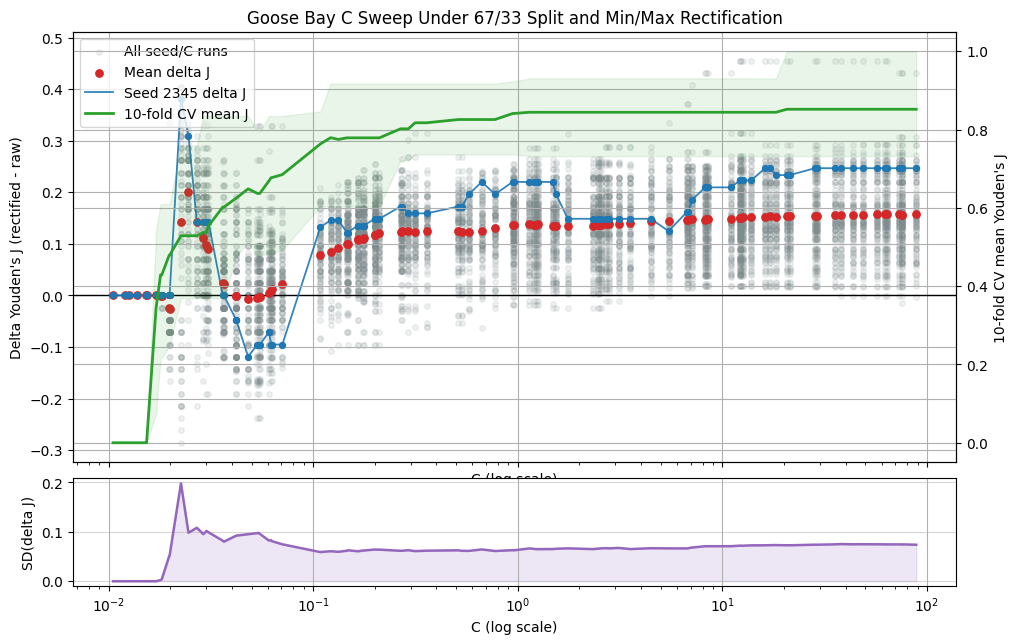

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\goose_bay_c_sweep_scatter.png


In [101]:
fig, (ax, ax_std) = plt.subplots(
    2,
    1,
    figsize=(11.4, 7.2),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.06},
)
ax.scatter(
    c_sweep_runs["c_value"],
    c_sweep_runs["delta_j"],
    s=16,
    alpha=0.12,
    color="#7f8c8d",
    label="All seed/C runs",
)
ax.scatter(
    c_sweep_summary["c_value"],
    c_sweep_summary["mean_delta_j"],
    s=28,
    color="#d62728",
    label="Mean delta J",
    zorder=4,
)
seed_2345_c = c_sweep_runs.loc[c_sweep_runs["seed"] == 2345].sort_values("c_value")
ax.plot(
    seed_2345_c["c_value"],
    seed_2345_c["delta_j"],
    color="#1f77b4",
    linewidth=1.3,
    alpha=0.9,
    label="Seed 2345 delta J",
    zorder=3,
)
ax.scatter(
    seed_2345_c["c_value"],
    seed_2345_c["delta_j"],
    s=18,
    color="#1f77b4",
    zorder=4,
)
ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Delta Youden's J (rectified - raw)")
ax.set_title("Goose Bay C Sweep Under 67/33 Split and Min/Max Rectification")

ax_cv = ax.twinx()
ax_cv.plot(
    c_sweep_cv_summary["c_value"],
    c_sweep_cv_summary["cv_mean_j"],
    color="#2ca02c",
    linewidth=2.0,
    label="10-fold CV mean J",
    zorder=5,
)
ax_cv.fill_between(
    c_sweep_cv_summary["c_value"],
    c_sweep_cv_summary["cv_p10_j"],
    c_sweep_cv_summary["cv_p90_j"],
    color="#2ca02c",
    alpha=0.10,
    zorder=2,
)
ax_cv.set_xscale("log")
ax_cv.set_ylabel("10-fold CV mean Youden's J")

handles, labels = ax.get_legend_handles_labels()
handles_cv, labels_cv = ax_cv.get_legend_handles_labels()
ax.legend(handles + handles_cv, labels + labels_cv, loc="upper left")

ax_std.plot(
    c_sweep_summary["c_value"],
    c_sweep_summary["std_delta_j"],
    color="#9467bd",
    linewidth=1.8,
)
ax_std.fill_between(
    c_sweep_summary["c_value"],
    0.0,
    c_sweep_summary["std_delta_j"],
    color="#9467bd",
    alpha=0.16,
)
ax_std.set_xscale("log")
ax_std.set_ylabel("SD(delta J)")
ax_std.set_xlabel("C (log scale)")
ax_std.grid(True, axis="y", alpha=0.5)
ax.tick_params(axis="x", labelbottom=False)
out_path = FIGURES_DIR / "goose_bay_c_sweep_scatter.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


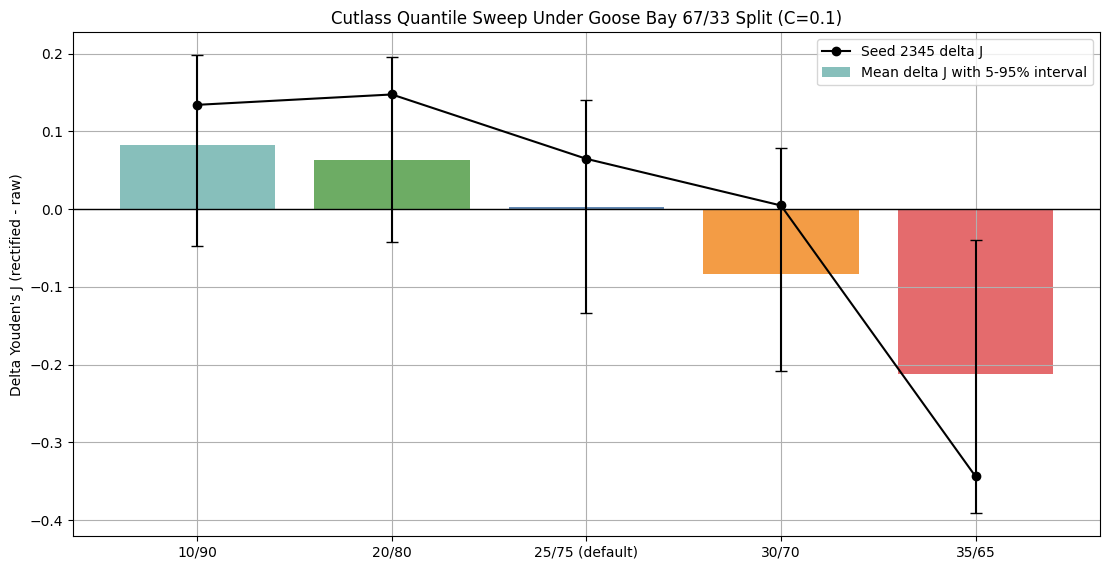

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\goose_bay_quantile_sweep.png


In [102]:
quantile_indexed = quantile_sweep_summary.set_index("quantile_id")
quantile_x = np.arange(len(QUANTILE_SWEEP_ORDER))
quantile_mean_delta = [quantile_indexed.loc[quantile_id, "mean_delta_j"] for quantile_id in QUANTILE_SWEEP_ORDER]
quantile_seed_delta = [quantile_indexed.loc[quantile_id, "seed_2345_delta_j"] for quantile_id in QUANTILE_SWEEP_ORDER]
quantile_lower = [
    quantile_indexed.loc[quantile_id, "mean_delta_j"] - quantile_indexed.loc[quantile_id, "p05_delta_j"]
    for quantile_id in QUANTILE_SWEEP_ORDER
]
quantile_upper = [
    quantile_indexed.loc[quantile_id, "p95_delta_j"] - quantile_indexed.loc[quantile_id, "mean_delta_j"]
    for quantile_id in QUANTILE_SWEEP_ORDER
]
quantile_colors = ["#76b7b2", "#59a14f", "#4c78a8", "#f28e2b", "#e15759"]

fig, ax = plt.subplots(figsize=(11.2, 5.8))
ax.bar(
    quantile_x,
    quantile_mean_delta,
    color=quantile_colors,
    yerr=[quantile_lower, quantile_upper],
    capsize=4,
    ecolor="black",
    alpha=0.88,
    label="Mean delta J with 5-95% interval",
)
ax.plot(
    quantile_x,
    quantile_seed_delta,
    color="black",
    marker="o",
    linewidth=1.5,
    label="Seed 2345 delta J",
)
ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_xticks(quantile_x)
ax.set_xticklabels([quantile_indexed.loc[quantile_id, "quantile_label"] for quantile_id in QUANTILE_SWEEP_ORDER])
ax.set_ylabel("Delta Youden's J (rectified - raw)")
ax.set_title("Cutlass Quantile Sweep Under Goose Bay 67/33 Split (C=0.1)")
ax.legend(loc="upper right")
fig.tight_layout()
out_path = FIGURES_DIR / "goose_bay_quantile_sweep.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


In [103]:
seed_2345 = repeated_runs[repeated_runs["seed"] == 2345].copy()
seed_2345["protocol"] = pd.Categorical(seed_2345["protocol"], categories=PROTOCOL_ORDER, ordered=True)
seed_2345 = seed_2345.sort_values("protocol").reset_index(drop=True)
seed_2345.to_csv(RUN_DIR / "goose_bay_seed2345_decomposition.csv", index=False)

seed_2345_table = seed_2345[
    [
        "protocol_label",
        "raw_j",
        "rect_j",
        "delta_j",
        "raw_tpr",
        "rect_tpr",
        "delta_tpr",
        "raw_tnr",
        "rect_tnr",
        "delta_tnr",
    ]
].copy()
for column in seed_2345_table.columns[1:]:
    seed_2345_table[column] = seed_2345_table[column].map(lambda value: format_numeric(value, 3))
seed_2345_table.to_csv(RUN_DIR / "goose_bay_seed2345_decomposition_formatted.csv", index=False)

paper_reference_table = pd.DataFrame(
    [
        {
            "source": "orender2022 paper",
            "raw_tpr": PAPER_REFERENCE["raw_tpr"],
            "raw_tnr": PAPER_REFERENCE["raw_tnr"],
            "raw_j": PAPER_REFERENCE["raw_j"],
            "rect_tpr": PAPER_REFERENCE["rect_tpr"],
            "rect_tnr": PAPER_REFERENCE["rect_tnr"],
            "rect_j": PAPER_REFERENCE["rect_j"],
            "delta_j": PAPER_REFERENCE["delta_j"],
        }
    ]
)
paper_reference_table.to_csv(RUN_DIR / "goose_bay_paper_reference.csv", index=False)

paper_reference_formatted = paper_reference_table.copy()
for column in paper_reference_formatted.columns[1:]:
    paper_reference_formatted[column] = paper_reference_formatted[column].map(lambda value: format_numeric(value, 3))
paper_reference_formatted.to_csv(RUN_DIR / "goose_bay_paper_reference_formatted.csv", index=False)

if display is not None:
    display(seed_2345_table)
    display(paper_reference_formatted)
else:
    print(seed_2345_table.to_string(index=False))
    print(paper_reference_formatted.to_string(index=False))


,protocol_label,raw_j,rect_j,delta_j,raw_tpr,rect_tpr,delta_tpr,raw_tnr,rect_tnr,delta_tnr
0,Generic probe,0.640,0.608,-0.033,0.956,0.897,-0.059,0.684,0.711,0.026
1,Split-matched cutlass,0.606,0.670,0.065,0.987,0.813,-0.173,0.619,0.857,0.238
2,Legacy rectifier bridge,0.606,0.714,0.109,0.987,1.000,0.013,0.619,0.714,0.095
3,Published-like legacy,0.695,0.905,0.210,0.933,1.000,0.067,0.762,0.905,0.143


,source,raw_tpr,raw_tnr,raw_j,rect_tpr,rect_tnr,rect_j,delta_j
0,orender2022 paper,0.933,0.762,0.695,0.973,0.881,0.854,0.159


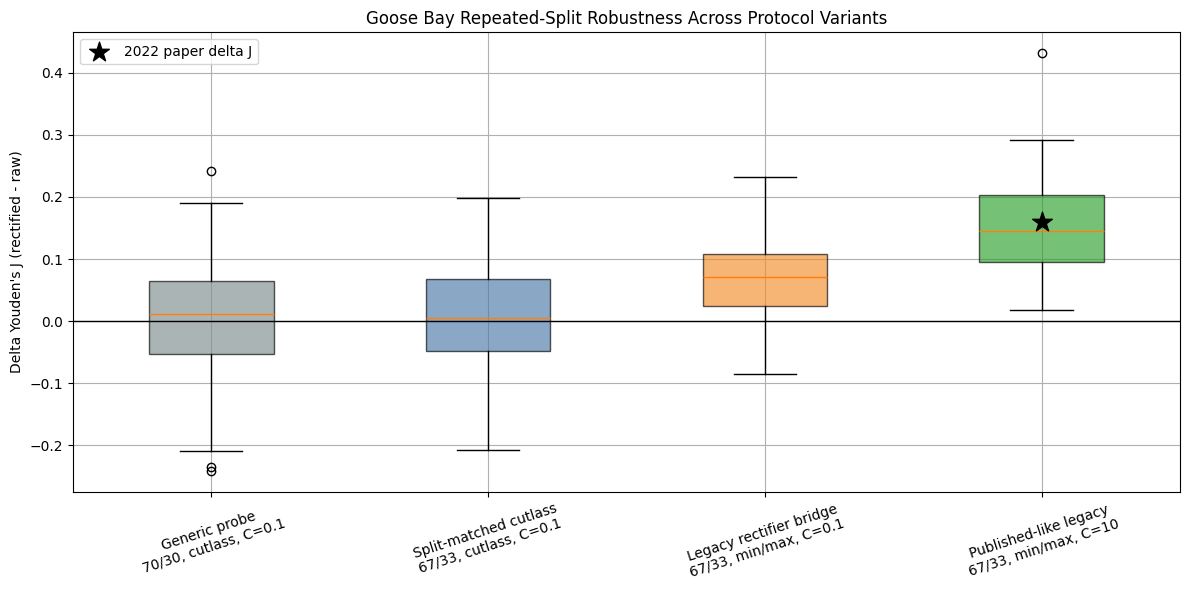

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\goose_bay_delta_j_protocols.png


In [104]:
fig, ax = plt.subplots(figsize=(12, 6))
data = [
    repeated_runs.loc[repeated_runs["protocol"] == protocol_id, "delta_j"].to_numpy()
    for protocol_id in PROTOCOL_ORDER
]
box = ax.boxplot(data, patch_artist=True, tick_labels=[PROTOCOL_DISPLAY[protocol_id] for protocol_id in PROTOCOL_ORDER])
for patch, protocol_id in zip(box["boxes"], PROTOCOL_ORDER):
    patch.set_facecolor(PROTOCOL_COLORS[protocol_id])
    patch.set_alpha(0.65)

ax.axhline(0.0, color="black", linewidth=1.0)
published_x = PROTOCOL_ORDER.index("published_like_legacy") + 1
ax.scatter(
    [published_x],
    [PAPER_REFERENCE["delta_j"]],
    marker="*",
    s=220,
    color="black",
    label="2022 paper delta J",
    zorder=5,
)
ax.set_ylabel("Delta Youden's J (rectified - raw)")
ax.set_title("Goose Bay Repeated-Split Robustness Across Protocol Variants")
ax.tick_params(axis="x", rotation=18)
ax.legend(loc="upper left")
fig.tight_layout()
out_path = FIGURES_DIR / "goose_bay_delta_j_protocols.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


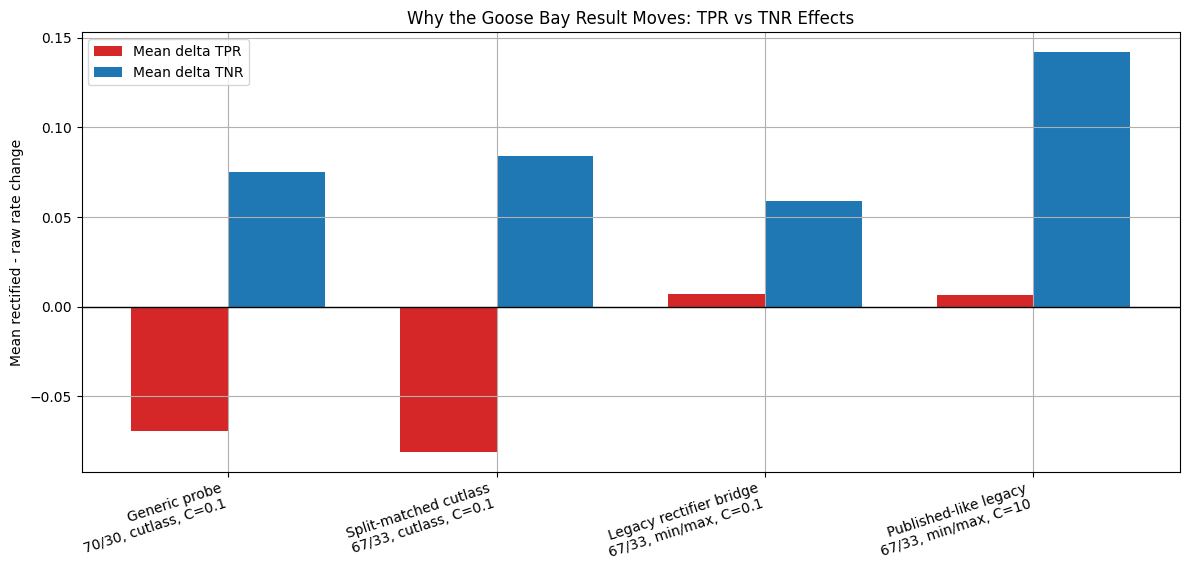

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\goose_bay_delta_components.png


In [105]:
x = np.arange(len(PROTOCOL_ORDER))
width = 0.36
summary_indexed = protocol_summary.set_index("protocol")

fig, ax = plt.subplots(figsize=(12, 5.8))
delta_tpr = [summary_indexed.loc[protocol_id, "mean_delta_tpr"] for protocol_id in PROTOCOL_ORDER]
delta_tnr = [summary_indexed.loc[protocol_id, "mean_delta_tnr"] for protocol_id in PROTOCOL_ORDER]
ax.bar(x - width / 2, delta_tpr, width=width, color="#d62728", label="Mean delta TPR")
ax.bar(x + width / 2, delta_tnr, width=width, color="#1f77b4", label="Mean delta TNR")
ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_xticks(x)
ax.set_xticklabels([PROTOCOL_DISPLAY[protocol_id] for protocol_id in PROTOCOL_ORDER], rotation=18, ha="right")
ax.set_ylabel("Mean rectified - raw rate change")
ax.set_title("Why the Goose Bay Result Moves: TPR vs TNR Effects")
ax.legend(loc="upper left")
fig.tight_layout()
out_path = FIGURES_DIR / "goose_bay_delta_components.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


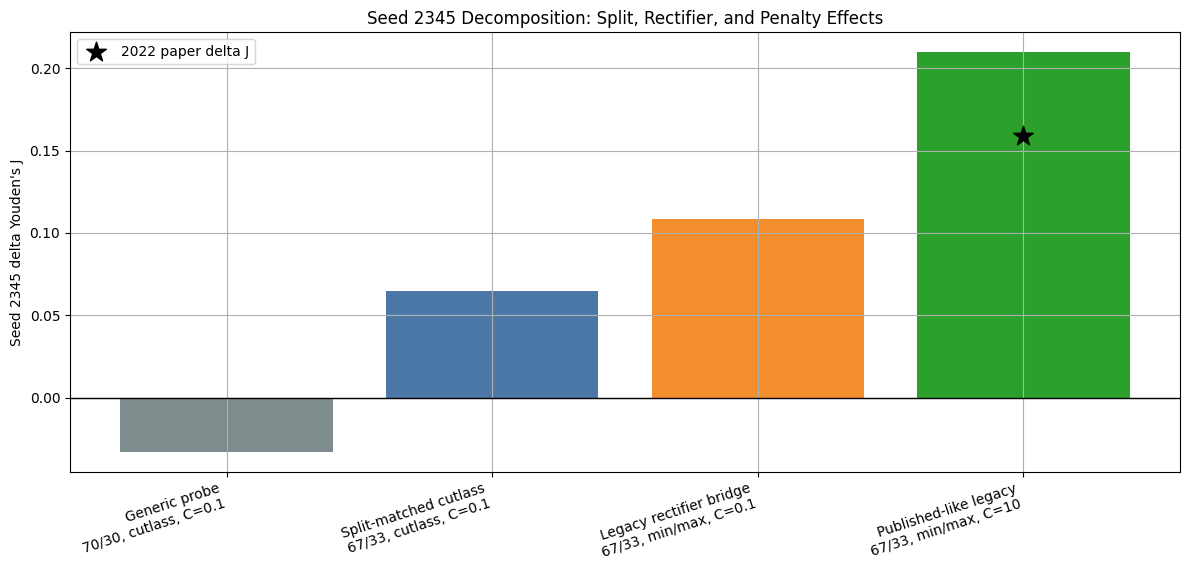

Saved: C:\Users\jason\ODU\dissertation\notebooks\Figures\goose_bay_seed2345_decomposition.png


In [106]:
seed_indexed = seed_2345.set_index("protocol")

fig, ax = plt.subplots(figsize=(12, 5.8))
seed_delta = [seed_indexed.loc[protocol_id, "delta_j"] for protocol_id in PROTOCOL_ORDER]
ax.bar(x, seed_delta, color=[PROTOCOL_COLORS[protocol_id] for protocol_id in PROTOCOL_ORDER])
ax.axhline(0.0, color="black", linewidth=1.0)
ax.scatter(
    [PROTOCOL_ORDER.index("published_like_legacy")],
    [PAPER_REFERENCE["delta_j"]],
    marker="*",
    s=220,
    color="black",
    label="2022 paper delta J",
    zorder=5,
)
ax.set_xticks(x)
ax.set_xticklabels([PROTOCOL_DISPLAY[protocol_id] for protocol_id in PROTOCOL_ORDER], rotation=18, ha="right")
ax.set_ylabel("Seed 2345 delta Youden's J")
ax.set_title("Seed 2345 Decomposition: Split, Rectifier, and Penalty Effects")
ax.legend(loc="upper left")
fig.tight_layout()
out_path = FIGURES_DIR / "goose_bay_seed2345_decomposition.png"
fig.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show(block=False)
print("Saved:", out_path)


In [107]:
summary_indexed = protocol_summary.set_index("protocol")
takeaways = [
    (
        "Changing the split alone is not enough: the mean delta J stays near zero when moving from the generic probe "
        f"({summary_indexed.loc['generic_probe', 'mean_delta_j']:.3f}) to split-matched cutlass "
        f"({summary_indexed.loc['matched_split_cutlass', 'mean_delta_j']:.3f})."
    ),
    (
        "Changing the rectifier matters: under the same 67/33 split and C=0.1, the mean delta J rises to "
        f"{summary_indexed.loc['legacy_rectifier_bridge', 'mean_delta_j']:.3f} and is positive on "
        f"{100.0 * summary_indexed.loc['legacy_rectifier_bridge', 'positive_fraction']:.1f}% of seeds."
    ),
    (
        "The published-like protocol is robust in this approximation: mean delta J is "
        f"{summary_indexed.loc['published_like_legacy', 'mean_delta_j']:.3f}, positive on "
        f"{100.0 * summary_indexed.loc['published_like_legacy', 'positive_fraction']:.1f}% of seeds, and close to the paper's delta J of "
        f"{PAPER_REFERENCE['delta_j']:.3f}."
    ),
    (
        "On seed 2345 specifically, the delta J progression is "
        f"{seed_indexed.loc['generic_probe', 'delta_j']:.3f} -> "
        f"{seed_indexed.loc['matched_split_cutlass', 'delta_j']:.3f} -> "
        f"{seed_indexed.loc['legacy_rectifier_bridge', 'delta_j']:.3f} -> "
        f"{seed_indexed.loc['published_like_legacy', 'delta_j']:.3f}, "
        "which indicates that rectification rule and penalty strength matter more than split matching alone."
    ),
]

takeaways_path = RUN_DIR / "goose_bay_takeaways.txt"
takeaways_path.write_text("\n".join(takeaways) + "\n", encoding="utf-8")

print("Goose Bay robustness takeaways:")
for line in takeaways:
    print("-", line)
print("Saved:", takeaways_path)


Goose Bay robustness takeaways:
- Changing the split alone is not enough: the mean delta J stays near zero when moving from the generic probe (0.006) to split-matched cutlass (0.003).
- Changing the rectifier matters: under the same 67/33 split and C=0.1, the mean delta J rises to 0.066 and is positive on 85.1% of seeds.
- The published-like protocol is robust in this approximation: mean delta J is 0.148, positive on 100.0% of seeds, and close to the paper's delta J of 0.159.
- On seed 2345 specifically, the delta J progression is -0.033 -> 0.065 -> 0.109 -> 0.210, which indicates that rectification rule and penalty strength matter more than split matching alone.
Saved: C:\Users\jason\ODU\dissertation\notebooks\runs_new\goose_bay_robustness\goose_bay_takeaways.txt


## Artifact Summary

The notebook writes the main tabular artifacts to:

- `notebooks/runs_new/goose_bay_robustness/goose_bay_repeated_protocol_runs.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_protocol_summary.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_protocol_summary_formatted.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_c_sweep_runs.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_c_sweep_summary.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_c_sweep_cv_summary.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_c_sweep_top10_formatted.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_quantile_sweep_runs.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_quantile_sweep_summary.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_quantile_sweep_summary_formatted.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_seed2345_decomposition.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_seed2345_decomposition_formatted.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_paper_reference.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_paper_reference_formatted.csv`
- `notebooks/runs_new/goose_bay_robustness/goose_bay_takeaways.txt`

and saves figures into `notebooks/Figures/`:

- `goose_bay_c_sweep_scatter.png`
- `goose_bay_delta_j_protocols.png`
- `goose_bay_delta_components.png`
- `goose_bay_quantile_sweep.png`
- `goose_bay_seed2345_decomposition.png`
